In [1]:
import pandas as pd
import tables

raw_df = pd.read_hdf('./VNAT_Dataframe_release.h5')
raw_df.head()

,connection,timestamps,sizes,directions,file_names
0,"(10.123.1.2, 1195, 10.123.1.1, 1195, 17)","[1563289706.330096, 1563289706.330207, 1563289...","[120, 88, 120, 88, 120, 88, 120, 120, 152, 120...","[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, ...",vpn_youtube_capture2.pcap
0,"(10.113.1.2, 22924, 10.115.1.2, 53, 17)","[1561391908.523659, 1561391908.524042]","[63, 79]","[1, 0]",nonvpn_sftp_newcapture1.pcap
1,"(10.113.1.2, 53065, 10.115.1.2, 53, 17)","[1561391908.523706, 1561391908.524059]","[63, 63]","[1, 0]",nonvpn_sftp_newcapture1.pcap
2,"(10.113.1.150, 39816, 10.115.1.123, 22, 6)","[1561391908.524836, 1561391908.525027, 1561391...","[60, 60, 52, 73, 52, 73, 52, 1378, 222, 52, 13...","[1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, ...",nonvpn_sftp_newcapture1.pcap
3,"(10.115.1.2, 6589, 10.113.1.2, 53, 17)","[1561391908.594887, 1561391908.595301]","[51, 102]","[1, 0]",nonvpn_sftp_newcapture1.pcap


In [2]:
#Parse file names to extract vpn vs non vpn
raw_df['is_vpn'] = raw_df['file_names'].str.startswith('vpn_')

# Extract app name from filename
raw_df['app'] = raw_df['file_names'].str.extract(r'(?:non)?vpn_(.+?)_(?:new)?capture')

# Map app to category
app_to_category = {
    'netflix':      'STREAMING',
    'youtube':      'STREAMING',
    'vimeo':        'STREAMING',
    'voip':         'VOIP',
    'skype-chat':   'CHAT',
    'sftp':         'FILE_TRANSFER',
    'scp':          'FILE_TRANSFER',
    'scp_long':     'FILE_TRANSFER',   # nonvpn_scp_long_capture1.pcap
    'rsync':        'FILE_TRANSFER',
    'ssh':          'FILE_TRANSFER',
    'rdp':          'C2',
}

raw_df['category'] = raw_df['app'].map(app_to_category)

raw_df.head()

,connection,timestamps,sizes,directions,file_names,is_vpn,app,category
0,"(10.123.1.2, 1195, 10.123.1.1, 1195, 17)","[1563289706.330096, 1563289706.330207, 1563289...","[120, 88, 120, 88, 120, 88, 120, 120, 152, 120...","[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, ...",vpn_youtube_capture2.pcap,True,youtube,STREAMING
0,"(10.113.1.2, 22924, 10.115.1.2, 53, 17)","[1561391908.523659, 1561391908.524042]","[63, 79]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,FILE_TRANSFER
1,"(10.113.1.2, 53065, 10.115.1.2, 53, 17)","[1561391908.523706, 1561391908.524059]","[63, 63]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,FILE_TRANSFER
2,"(10.113.1.150, 39816, 10.115.1.123, 22, 6)","[1561391908.524836, 1561391908.525027, 1561391...","[60, 60, 52, 73, 52, 73, 52, 1378, 222, 52, 13...","[1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, ...",nonvpn_sftp_newcapture1.pcap,False,sftp,FILE_TRANSFER
3,"(10.115.1.2, 6589, 10.113.1.2, 53, 17)","[1561391908.594887, 1561391908.595301]","[51, 102]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,FILE_TRANSFER


In [3]:
# Label Distribution & Filename Validation 
# raw_df has duplicate index labels from the HDF5 load; reset for safe ops
df = raw_df.reset_index(drop=True)

# 1. Malformed filenames: regex failed to extract app name
malformed = df[df['app'].isna()]
print(f"Malformed filenames (app extraction failed): {len(malformed)}")
if not malformed.empty:
    print(malformed['file_names'].unique())

# 2. Unmapped apps: app extracted but not in app_to_category
unmapped = df[df['app'].notna() & df['category'].isna()]
print(f"\nUnmapped app names (no category assignment): {len(unmapped)}")
if not unmapped.empty:
    print(unmapped[['file_names', 'app']].drop_duplicates())

# 3. All unique filenames eyeball for anomalies
print(f"\nAll unique file_names ({df['file_names'].nunique()} total):")
print(sorted(df['file_names'].unique()))

# 4. Label distributions
print("\n VPN Status")
print(df['is_vpn'].value_counts())

print("\n Traffic Category")
print(df['category'].value_counts(dropna=False))

print("\n Application ")
print(df['app'].value_counts(dropna=False))

# 5. Cross-tab: category Ã— vpn
print("\n Category Ã— VPN Status")
print(pd.crosstab(df['category'], df['is_vpn'], margins=True))

Malformed filenames (app extraction failed): 0

Unmapped app names (no category assignment): 0

All unique file_names (165 total):
['nonvpn_netflix_capture1.pcap', 'nonvpn_netflix_capture2.pcap', 'nonvpn_rdp_capture1.pcap', 'nonvpn_rdp_capture2.pcap', 'nonvpn_rdp_capture3.pcap', 'nonvpn_rdp_capture4.pcap', 'nonvpn_rdp_capture_5.pcap', 'nonvpn_rsync_capture1.pcap', 'nonvpn_rsync_newcapture1.pcap', 'nonvpn_scp_capture1.pcap', 'nonvpn_scp_long_capture1.pcap', 'nonvpn_scp_newcapture1.pcap', 'nonvpn_sftp_capture1.pcap', 'nonvpn_sftp_capture2.pcap', 'nonvpn_sftp_capture3.pcap', 'nonvpn_sftp_newcapture1.pcap', 'nonvpn_sftp_newcapture2.pcap', 'nonvpn_skype-chat_capture1.pcap', 'nonvpn_skype-chat_capture10.pcap', 'nonvpn_skype-chat_capture11.pcap', 'nonvpn_skype-chat_capture12.pcap', 'nonvpn_skype-chat_capture13.pcap', 'nonvpn_skype-chat_capture14.pcap', 'nonvpn_skype-chat_capture15.pcap', 'nonvpn_skype-chat_capture16.pcap', 'nonvpn_skype-chat_capture17.pcap', 'nonvpn_skype-chat_capture18.pcap'

In [4]:
# Per-flow stats
df['pkt_count']   = df['sizes'].apply(len)
df['duration']    = df['timestamps'].apply(lambda t: t[-1] - t[0] if len(t) > 1 else 0.0)
df['total_bytes'] = df['sizes'].apply(sum)

df[['pkt_count', 'duration', 'total_bytes']].describe()

,pkt_count,duration,total_bytes
count,3.371100e+04,33711.000000,3.371100e+04
mean,1.130292e+03,379.621814,1.037376e+06
std,3.741679e+04,2480.214637,3.704212e+07
min,1.000000e+00,0.000000,2.100000e+01
25%,2.000000e+00,0.000358,1.260000e+02
50%,2.000000e+00,0.000415,1.340000e+02
75%,2.000000e+00,0.000600,1.530000e+02
max,3.842411e+06,142910.249806,3.858275e+09


In [5]:
# Data quality issues 
empty_flows  = df[df['pkt_count'] == 0]
single_flows = df[df['pkt_count'] == 1]

print(f"Empty flows (0 packets):        {len(empty_flows)}")
print(f"Single-packet flows (duration=0): {len(single_flows)}")
print(f"\nTop outliers by packet count:")
print(df['pkt_count'].nlargest(5))
print(f"\nTop outliers by total bytes:")
print(df['total_bytes'].nlargest(5))

Empty flows (0 packets):        0
Single-packet flows (duration=0): 27

Top outliers by packet count:
12325    3842411
972      3739465
12464    2240881
3        2002346
13924    1361406
Name: pkt_count, dtype: int64

Top outliers by total bytes:
12325    3858275080
972      3811032904
12464    2234841512
3        1826811992
13924    1359311728
Name: total_bytes, dtype: int64


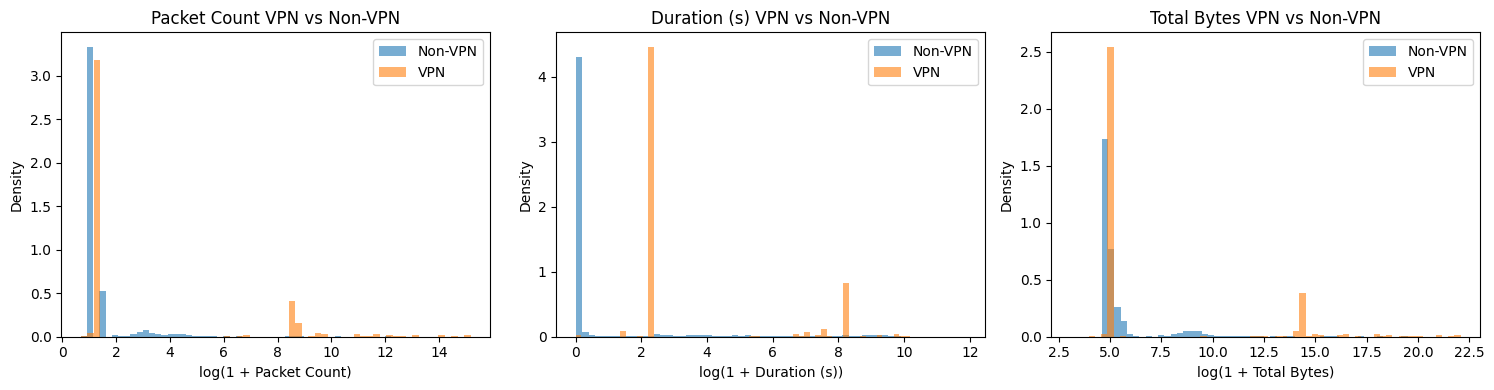

In [6]:
# Distributions: VPN vs Non-VPN
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('pkt_count', 'Packet Count'), ('duration', 'Duration (s)'), ('total_bytes', 'Total Bytes')]

for ax, (col, label) in zip(axes, metrics):
    for is_vpn, grp in df.groupby('is_vpn'):
        vals = np.log1p(grp[col])
        ax.hist(vals, bins=60, alpha=0.6, label='VPN' if is_vpn else 'Non-VPN', density=True)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} VPN vs Non-VPN')
    ax.legend()

plt.tight_layout()
plt.show()

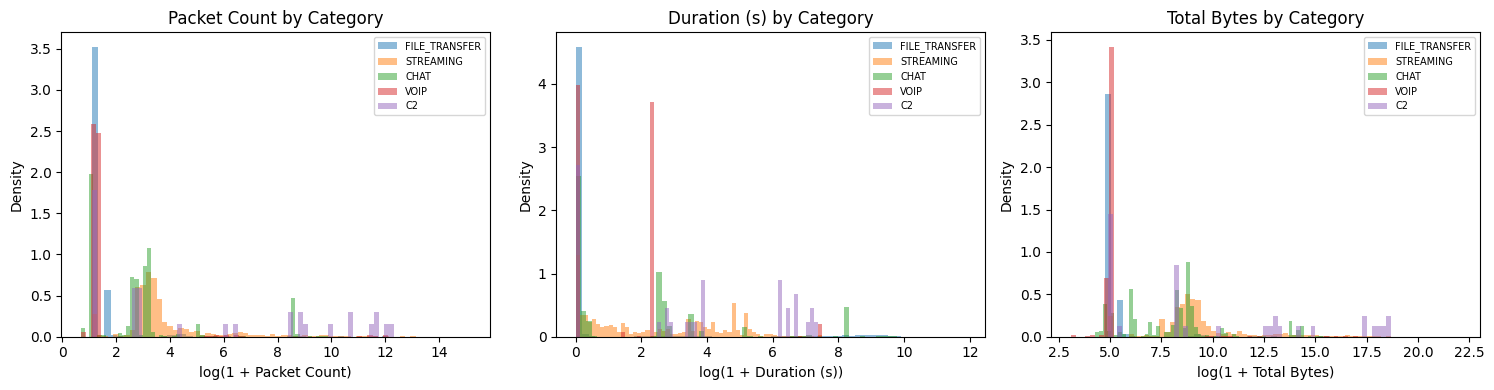

In [7]:
# Distributions: across 5 traffic categorie
cat_df = df.dropna(subset=['category'])
category_order = cat_df['category'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, metrics):
    for cat in category_order:
        vals = np.log1p(cat_df.loc[cat_df['category'] == cat, col])
        ax.hist(vals, bins=60, alpha=0.5, label=cat, density=True)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} by Category')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [8]:
# Drop unusable flows
# Single-packet flows: no inter-arrival times, timing features undefined.
# Unlabelled rows: guard in case scp_long fix not yet applied.
clean_df = df[(df['pkt_count'] > 1) & df['category'].notna()].copy()
print(f"Rows before: {len(df):,}  ->  after dropping single-pkt & unlabelled: {len(clean_df):,}")
print(clean_df['category'].value_counts())

Rows before: 33,711  ->  after dropping single-pkt & unlabelled: 33,684
category
FILE_TRANSFER    29993
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64


In [9]:
import sys
from src.feature_engineering import extract_features
print('extract_features imported from src/feature_engineering.py')

extract_features imported from src/feature_engineering.py


In [10]:
# Apply feature extraction (~2-5 min for 33k rows)
from tqdm.notebook import tqdm
tqdm.pandas()

feat_records = clean_df.progress_apply(extract_features, axis=1)
feat_matrix  = pd.DataFrame(feat_records.tolist(), index=clean_df.index)

print(f'Feature matrix: {feat_matrix.shape}')
print('NaN counts (should all be 0):')
print(feat_matrix.isna().sum().value_counts())

  0%|          | 0/33684 [00:00<?, ?it/s]

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 12 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Feature matrix: (33684, 113)
NaN counts (should all be 0):
0        41
25569    36
25912    36
Name: count, dtype: int64


In [11]:
nan_mask = feat_matrix['out_log_mean_detail_coeffs_1'].isna()
print("Flows WITH wavelet NaNs:")
print(clean_df.loc[feat_matrix.index[nan_mask], 'pkt_count'].describe())
print("\nFlows WITHOUT wavelet NaNs:")
print(clean_df.loc[feat_matrix.index[~nan_mask], 'pkt_count'].describe())


Flows WITH wavelet NaNs:
count    25569.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: pkt_count, dtype: float64

Flows WITHOUT wavelet NaNs:
count    8.115000e+03
mean     4.689107e+03
std      7.615609e+04
min      2.000000e+00
25%      4.000000e+00
50%      4.000000e+00
75%      2.900000e+01
max      3.842411e+06
Name: pkt_count, dtype: float64


In [13]:
# Assemble final labelled feature dataframe
# Reset index so concat aligns correctly, fill NaNs from direction-only flows
# (e.g. all-outbound flows produce NaN for in_* wavelet features).
feat_matrix_reset = feat_matrix.reset_index(drop=True)
label_cols = clean_df[['is_vpn', 'app', 'category']].reset_index(drop=True)

features = pd.concat([feat_matrix_reset, label_cols], axis=1).fillna(0)

print(features.shape)
features.head()

(33684, 116)


,log_out_pkt_count,log_in_pkt_count,log_out_bytes,log_in_bytes,dir_ratio,bytes_per_sec,out_size_min,out_size_max,out_size_mean,out_size_std,...,in_rel_energy_10,in_log_mean_detail_coeffs_11,in_log_std_dev_detail_coeffs_11,in_rel_energy_11,in_log_mean_detail_coeffs_12,in_log_std_dev_detail_coeffs_12,in_rel_energy_12,is_vpn,app,category
0,9.916108,10.646163,14.852035,17.832095,0.048335,7.286141e+04,88.0,1448.0,139.209006,129.238237,...,0.010160,5.500812,5.912749,0.012785,5.276400,5.902365,0.024993,True,youtube,STREAMING
1,0.693147,0.693147,4.158883,4.382027,0.443662,3.708538e+05,63.0,63.0,63.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER
2,0.693147,0.693147,4.158883,4.158883,0.500000,3.568415e+05,63.0,63.0,63.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER
3,13.732254,13.894537,20.328655,20.865520,0.368917,3.859252e+06,52.0,1378.0,732.455010,659.871083,...,0.024525,2.683066,3.782950,0.052880,2.352396,3.466488,0.055188,False,sftp,FILE_TRANSFER
4,0.693147,0.693147,3.951244,4.634729,0.333333,3.696593e+05,51.0,51.0,51.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER


In [14]:
# Drop wavelet features — unreliable for short flows (pkt_count=2), 
# which make up ~76% of data. 41 clean features remain.
wavelet_cols = [c for c in features.columns if 'detail_coeffs' in c or 'rel_energy' in c]
features = features.drop(columns=wavelet_cols)
print(f"Dropped {len(wavelet_cols)} wavelet cols → {features.shape[1]} features remain")


Dropped 72 wavelet cols → 44 features remain


In [15]:
import os
os.makedirs('data', exist_ok=True)
features.to_csv('data/features.csv', index=False)
print(f'Saved data/features.csv  ({features.shape[0]:,} rows x {features.shape[1]} cols)')
print(features['category'].value_counts())

Saved data/features.csv  (33,684 rows x 44 cols)
category
FILE_TRANSFER    29993
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64
